## EDA ADHD EEG dataset

In [ ]:
import sys
sys.path.insert(0, '../..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.signal import welch

from adhd_classifier.data_loader import load_data, subject_split, EEG_CHANNELS, SAMPLING_FREQ

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

DATA_PATH = '../../adhd_classifier/data/adhdata.csv'


Data loading

In [ ]:
df = load_data(DATA_PATH)
print(f"shape: {df.shape}")
df.head(3)

loaded 2,166,383 samples | 121 subjects (61 ADHD, 60 Control)
shape: (2166383, 22)


,Fp1,Fp2,F3,F4,C3,C4,P3,P4,O1,O2,...,T7,T8,P7,P8,Fz,Cz,Pz,Class,ID,label
0,261.0,402.0,16.0,261.0,126.0,384.0,126.0,236.0,52.0,236.0,...,200.0,494.0,126.0,236.0,121.0,367.0,121.0,ADHD,v10p,1
1,121.0,191.0,-94.0,85.0,16.0,200.0,126.0,52.0,347.0,273.0,...,126.0,347.0,52.0,52.0,15.0,121.0,-19.0,ADHD,v10p,1
2,-55.0,85.0,-204.0,15.0,-57.0,200.0,52.0,126.0,236.0,200.0,...,126.0,420.0,52.0,126.0,-55.0,261.0,85.0,ADHD,v10p,1


Raw EEG signal visualization

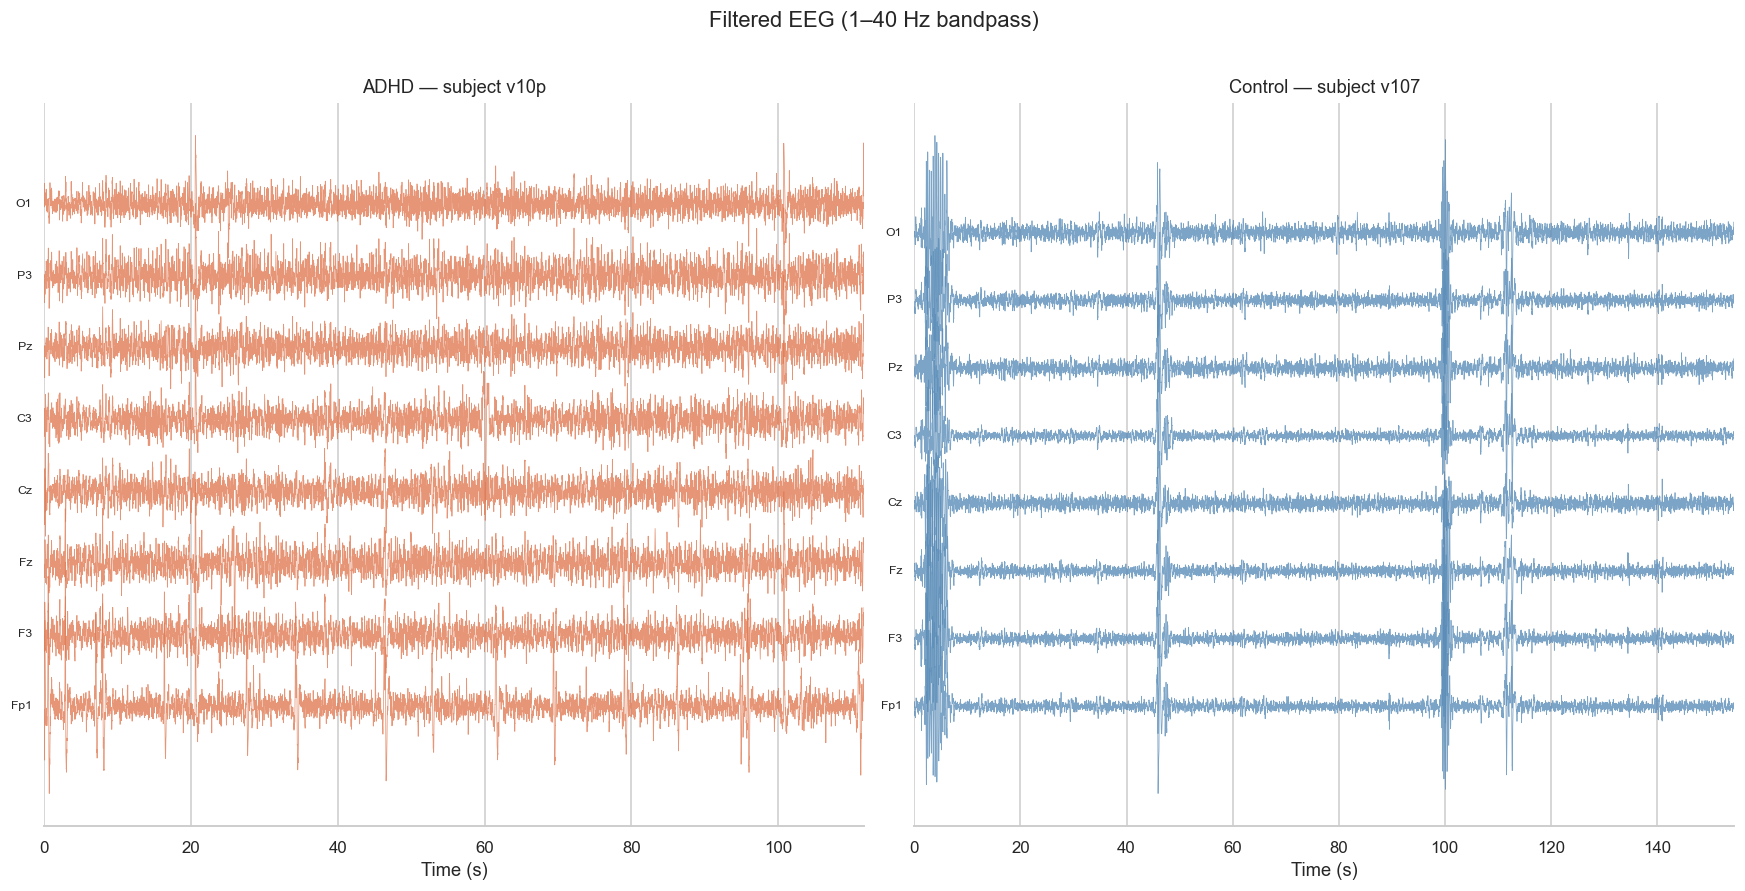

In [ ]:
from scipy.signal import butter, filtfilt

def bandpass_filter(data, lo=1.0, hi=40.0, fs=SAMPLING_FREQ, order=4):
    nyq = fs / 2.0
    b, a = butter(order, [lo / nyq, hi / nyq], btype='band')
    return filtfilt(b, a, data, axis=0)

PLOT_CHANNELS = ['Fp1', 'F3', 'Fz', 'Cz', 'C3', 'Pz', 'P3', 'O1']

adhd_id = df[df['label'] == 1]['ID'].unique()[0]
ctrl_id = df[df['label'] == 0]['ID'].unique()[0]

adhd_seg = bandpass_filter(df[df['ID'] == adhd_id][PLOT_CHANNELS].values)
ctrl_seg = bandpass_filter(df[df['ID'] == ctrl_id][PLOT_CHANNELS].values)

fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharey=False)

for ax, seg, title, color in [
    (axes[0], adhd_seg, f'ADHD — subject {adhd_id}', '#e07b54'),
    (axes[1], ctrl_seg, f'Control — subject {ctrl_id}', '#5b8db8'),
]:
    n = len(seg)
    t = np.arange(n) / SAMPLING_FREQ
    spacing = int(np.ptp(seg) / len(PLOT_CHANNELS) * 2.2) or 1
    for i, ch in enumerate(PLOT_CHANNELS):
        offset = i * spacing
        ax.plot(t, seg[:, i] + offset, lw=0.5, color=color, alpha=0.8)
        ax.text(-0.015, offset, ch, ha='right', va='center', fontsize=8,
                transform=ax.get_yaxis_transform())
    ax.set_title(title)
    ax.set_xlabel('Time (s)')
    ax.set_yticks([])
    ax.set_xlim(0, n / SAMPLING_FREQ)
    ax.spines[['left', 'top', 'right']].set_visible(False)

plt.suptitle('Filtered EEG (1–40 Hz bandpass)', y=1.01)
plt.tight_layout()
plt.show()


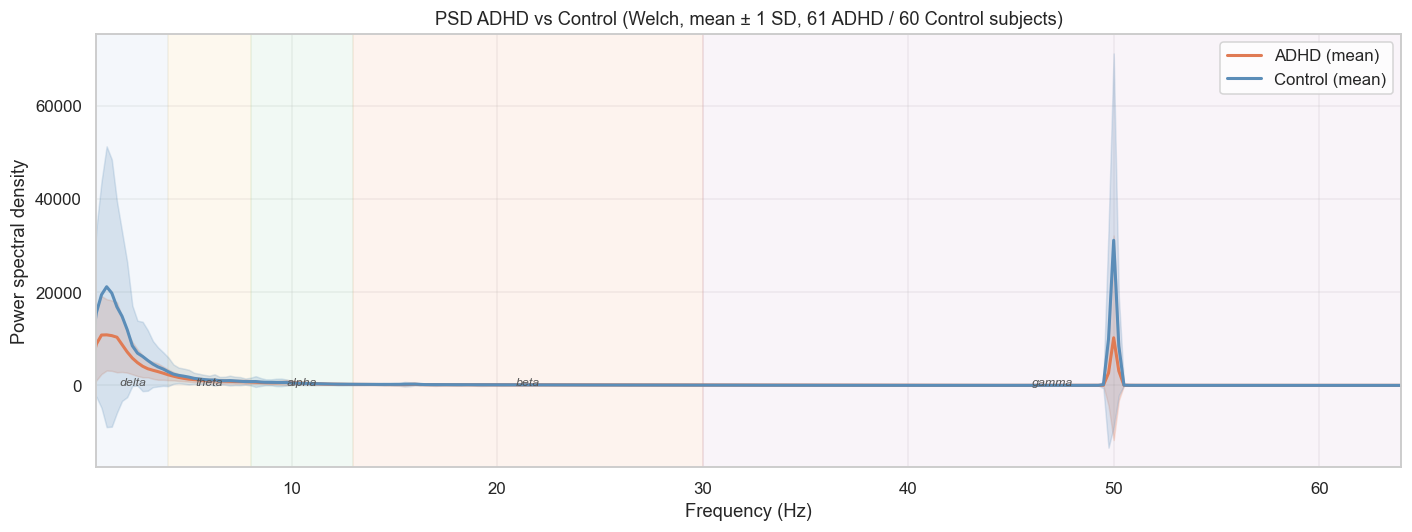

In [ ]:
BAND_REGIONS = {
    'delta': (0.5, 4.0,  '#a8c4e0'),
    'theta': (4.0, 8.0,  '#f5c97a'),
    'alpha': (8.0, 13.0, '#90d4a8'),
    'beta':  (13.0, 30.0,'#f5a07a'),
    'gamma': (30.0, 64.0,'#d4a8d4'),
}

def mean_psd(group):
    signal = group[EEG_CHANNELS].values
    n = signal.shape[0]
    nperseg = min(n, SAMPLING_FREQ * 4)
    all_psd = []
    for ch_idx in range(signal.shape[1]):
        freqs, psd = welch(signal[:, ch_idx], fs=SAMPLING_FREQ, nperseg=nperseg)
        all_psd.append(psd)
    return freqs, np.mean(all_psd, axis=0)

adhd_subjects = df[df['label'] == 1]['ID'].unique()
ctrl_subjects  = df[df['label'] == 0]['ID'].unique()

adhd_psds, ctrl_psds, freqs = [], [], None
for sid in adhd_subjects:
    f, p = mean_psd(df[df['ID'] == sid])
    freqs = f
    adhd_psds.append(p)
for sid in ctrl_subjects:
    _, p = mean_psd(df[df['ID'] == sid])
    ctrl_psds.append(p)

adhd_mean = np.mean(adhd_psds, axis=0)
adhd_std  = np.std(adhd_psds, axis=0)
ctrl_mean = np.mean(ctrl_psds, axis=0)
ctrl_std  = np.std(ctrl_psds, axis=0)

n_a, n_c = len(adhd_subjects), len(ctrl_subjects)

fig, ax = plt.subplots(figsize=(13, 5))

for band, (lo, hi, color) in BAND_REGIONS.items():
    ax.axvspan(lo, hi, alpha=0.12, color=color)
    ax.text((lo + hi) / 2, ax.get_ylim()[1] if ax.get_ylim()[1] != 1 else 1,
            band, ha='center', fontsize=8, color='#555555', style='italic')

ax.plot(freqs, adhd_mean, color='#e07b54', lw=2.0, label='ADHD (mean)')
ax.fill_between(freqs, adhd_mean - adhd_std, adhd_mean + adhd_std, alpha=0.2, color='#e07b54')

ax.plot(freqs, ctrl_mean, color='#5b8db8', lw=2.0, label='Control (mean)')
ax.fill_between(freqs, ctrl_mean - ctrl_std, ctrl_mean + ctrl_std, alpha=0.2, color='#5b8db8')

ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Power spectral density')
ax.set_title(f'PSD ADHD vs Control (Welch, mean ± 1 SD, {n_a} ADHD / {n_c} Control subjects)')
ax.set_xlim(0.5, freqs[-1])
ax.legend(loc='upper right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


Class and subject distribution

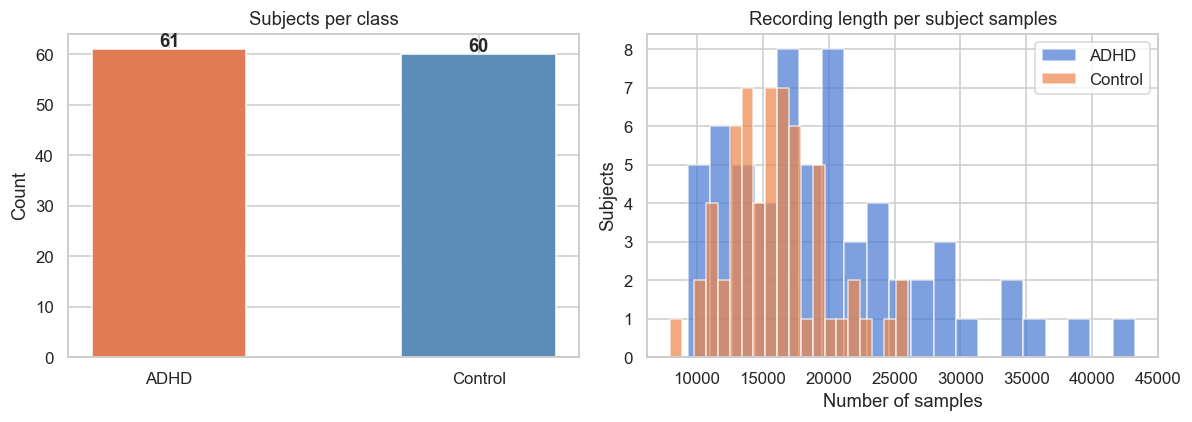

         count     mean     std     min      25%      50%      75%      max
Class                                                                      
ADHD      61.0  19788.0  7442.0  9286.0  14304.0  18389.0  23681.0  43252.0
Control   60.0  15989.0  3828.0  7983.0  13390.0  15629.0  17805.0  25985.0


In [ ]:
subject_info = df.groupby('ID').agg(
    label=('label', 'first'),
    n_samples=('label', 'count')
).reset_index()
subject_info['Class'] = subject_info['label'].map({1: 'ADHD', 0: 'Control'})

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

counts = subject_info['Class'].value_counts()
axes[0].bar(counts.index, counts.values, color=['#e07b54', '#5b8db8'], edgecolor='white', width=0.5)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 0.5, str(v), ha='center', fontweight='bold')
axes[0].set_title('Subjects per class')
axes[0].set_ylabel('Count')

for cls, grp in subject_info.groupby('Class'):
    axes[1].hist(grp['n_samples'], bins=20, alpha=0.7, label=cls)
axes[1].set_title('Recording length per subject samples')
axes[1].set_xlabel('Number of samples')
axes[1].set_ylabel('Subjects')
axes[1].legend()

plt.tight_layout()
plt.show()

print(subject_info.groupby('Class')['n_samples'].describe().round(0))

Missing values and basic signal quality

In [ ]:
missing = df[EEG_CHANNELS].isnull().sum()
print("missing values per channel:")
print(missing[missing > 0] if missing.any() else "none.")

desc = df[EEG_CHANNELS].describe().T[['mean', 'std', 'min', 'max']]
print(f"\nglobal amplitude range: [{desc['min'].min():.2f}, {desc['max'].max():.2f}]")
print(f"mean std across channels: {desc['std'].mean():.4f}")
desc

missing values per channel:
none.

global amplitude range: [-13237.00, 13813.00]
mean std across channels: 228.3302


,mean,std,min,max
Fp1,136.090300,275.549744,-3786.0,13813.0
Fp2,136.161874,275.513564,-13224.0,4802.0
F3,142.211730,220.650336,-3921.0,5020.0
F4,136.102201,213.387265,-13237.0,4802.0
F7,142.059967,243.208694,-3995.0,5020.0
F8,141.563308,226.518631,-3958.0,5020.0
C3,142.273664,223.485244,-3921.0,5430.0
C4,142.200533,210.719453,-3921.0,5020.0
Cz,135.183036,213.029495,-3751.0,4802.0
T7,141.745176,227.233709,-3958.0,5020.0


Signal amplitude distribution

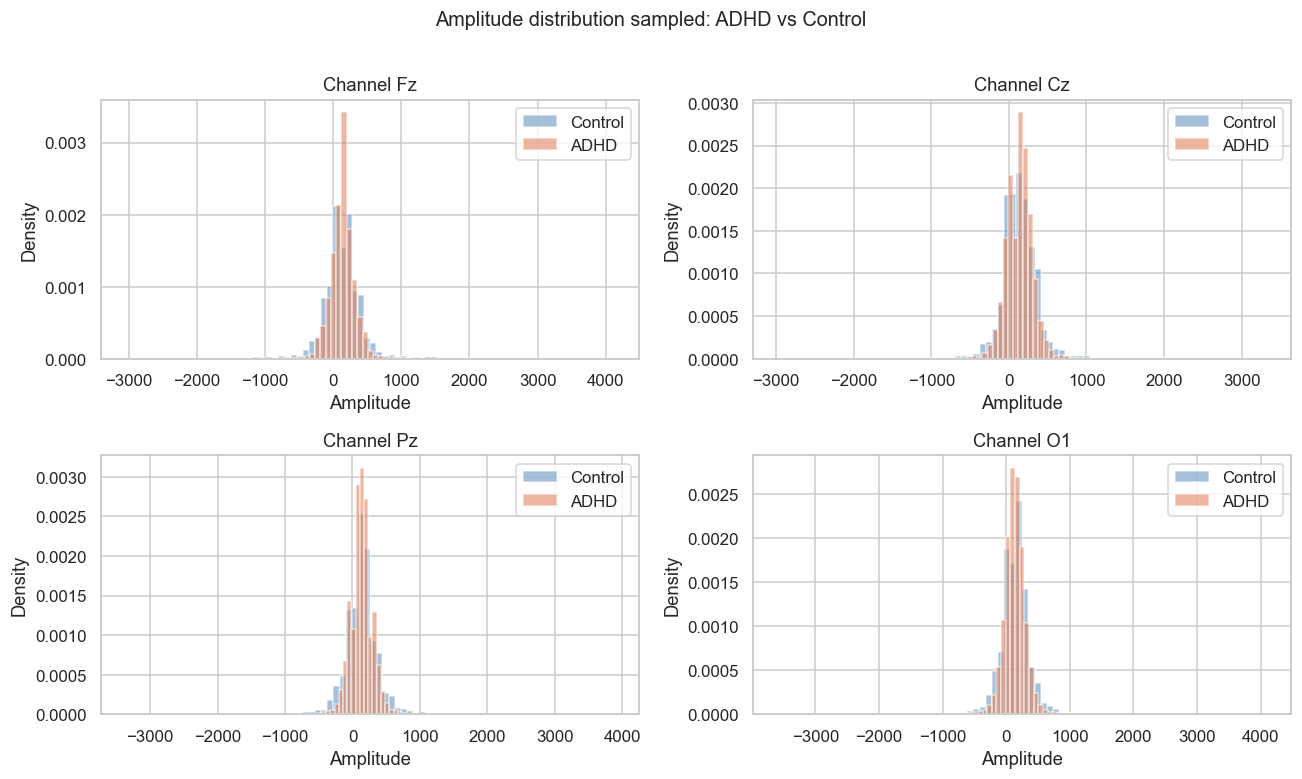

In [ ]:
sample = df.sample(n=min(50000, len(df)), random_state=42)

channels_plot = ['Fz', 'Cz', 'Pz', 'O1']

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
axes = axes.flatten()

for ax, ch in zip(axes, channels_plot):
    for label, color, name in [(0, '#5b8db8', 'Control'), (1, '#e07b54', 'ADHD')]:
        vals = sample[sample['label'] == label][ch]
        ax.hist(vals, bins=80, alpha=0.55, color=color, label=name, density=True)
    ax.set_title(f'Channel {ch}')
    ax.set_xlabel('Amplitude')
    ax.set_ylabel('Density')
    ax.legend()

plt.suptitle('Amplitude distribution sampled: ADHD vs Control', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

Per-channel mean amplitude — ADHD vs Control

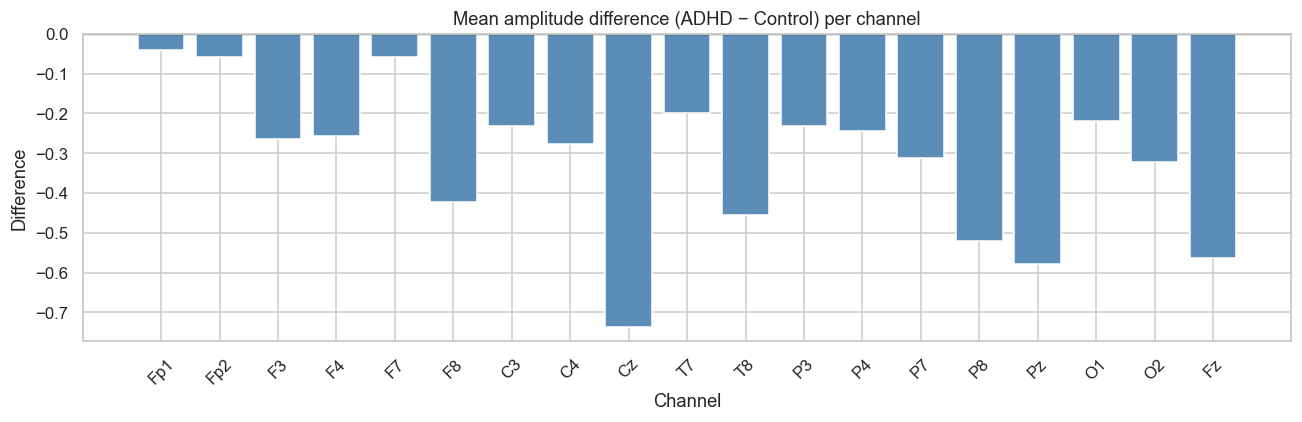

In [ ]:
subj_means = df.groupby(['ID', 'label'])[EEG_CHANNELS].mean().reset_index()

ch_stats = subj_means.groupby('label')[EEG_CHANNELS].mean().T
ch_stats.columns = ['Control', 'ADHD']
ch_stats['diff'] = ch_stats['ADHD'] - ch_stats['Control']

fig, ax = plt.subplots(figsize=(12, 4))
colors = ['#e07b54' if v > 0 else '#5b8db8' for v in ch_stats['diff']]
ax.bar(ch_stats.index, ch_stats['diff'], color=colors, edgecolor='white')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Mean amplitude difference (ADHD − Control) per channel')
ax.set_xlabel('Channel')
ax.set_ylabel('Difference')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

Frequency band power: ADHD vs Control

In [ ]:
FREQ_BANDS = {
    'delta': (0.5, 4.0),
    'theta': (4.0, 8.0),
    'alpha': (8.0, 13.0),
    'beta':  (13.0, 30.0),
}

def subject_band_powers(group):
    signal = group[EEG_CHANNELS].values
    n = signal.shape[0]
    nperseg = min(n, SAMPLING_FREQ * 4)
    row = {}
    for band, (lo, hi) in FREQ_BANDS.items():
        powers = []
        for ch_idx in range(signal.shape[1]):
            freqs, psd = welch(signal[:, ch_idx], fs=SAMPLING_FREQ, nperseg=nperseg)
            mask = (freqs >= lo) & (freqs < hi)
            powers.append(np.trapezoid(psd[mask], freqs[mask]))
        row[band] = np.mean(powers)
    return pd.Series(row)


band_df = df.groupby(['ID', 'label']).apply(subject_band_powers, include_groups=False).reset_index()
band_df['Class'] = band_df['label'].map({1: 'ADHD', 0: 'Control'})
print("computied band powers")
band_df.head(3)


computied band powers


,ID,label,delta,theta,alpha,beta,Class
0,v107,0,80244.767259,9094.989489,2860.664127,2088.210152,Control
1,v108,0,39421.061075,2628.581998,1475.305560,740.622615,Control
2,v109,0,237118.694484,10382.359297,4327.501592,5110.870382,Control


C:\Users\kamil\AppData\Local\Temp\ipykernel_47352\441298299.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=band_df, x='Class', y=band, ax=ax,
C:\Users\kamil\AppData\Local\Temp\ipykernel_47352\441298299.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=band_df, x='Class', y=band, ax=ax,
C:\Users\kamil\AppData\Local\Temp\ipykernel_47352\441298299.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=band_df, x='Class', y=band, ax=ax,
C:\Users\kamil\AppData\Local\Temp\ipykernel_47352\441298299.py:7: FutureWarning: 

Passin

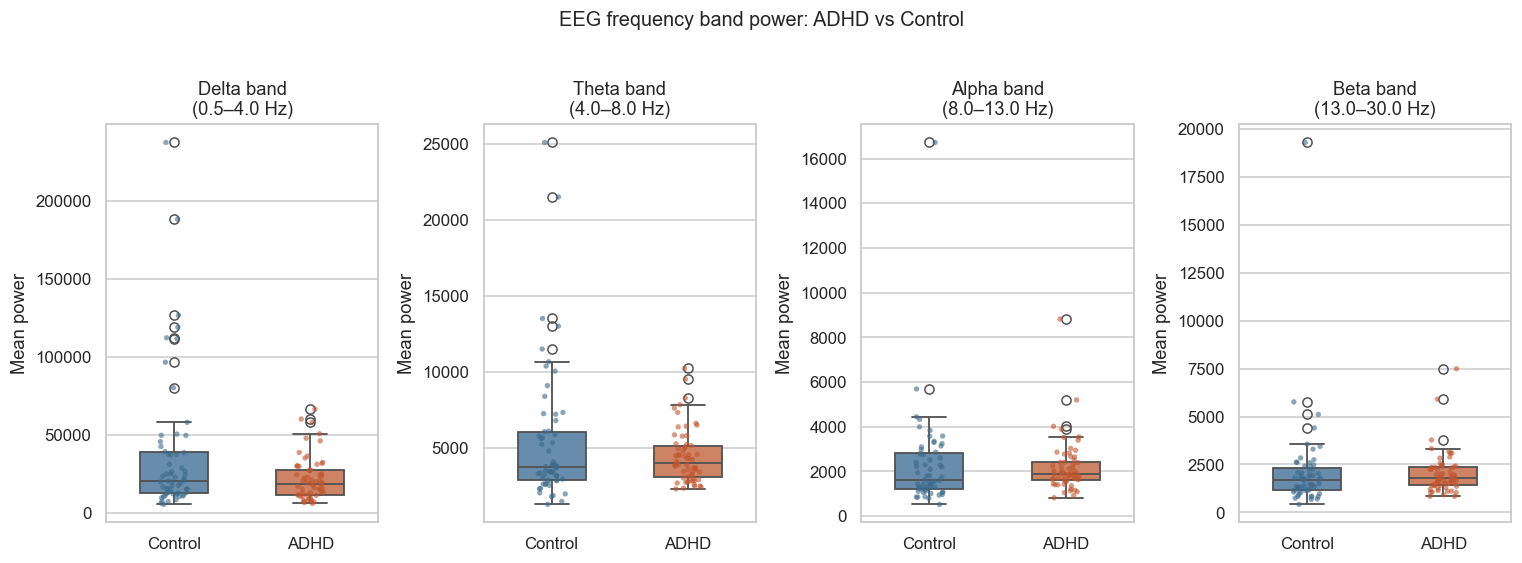

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(14, 5))

for ax, band in zip(axes, FREQ_BANDS):
    sns.boxplot(data=band_df, x='Class', y=band, ax=ax,
                palette={'ADHD': '#e07b54', 'Control': '#5b8db8'},
                width=0.5, linewidth=1.2)
    sns.stripplot(data=band_df, x='Class', y=band, ax=ax,
                  palette={'ADHD': '#c0552e', 'Control': '#3d6a8a'},
                  size=3.5, alpha=0.6, jitter=True)
    ax.set_title(f'{band.capitalize()} band\n({FREQ_BANDS[band][0]}–{FREQ_BANDS[band][1]} Hz)')
    ax.set_xlabel('')
    ax.set_ylabel('Mean power')

plt.suptitle('EEG frequency band power: ADHD vs Control', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

Topographic maps band power

In [ ]:
from scipy.interpolate import CloughTocher2DInterpolator

POS_1020 = {
    'Fp1': (-0.18,  0.92), 'Fp2': ( 0.18,  0.92),
    'F7':  (-0.71,  0.55), 'F3':  (-0.40,  0.58), 'Fz':  ( 0.00,  0.65), 'F4':  ( 0.40,  0.58), 'F8':  ( 0.71,  0.55),
    'T7':  (-0.95,  0.00), 'C3':  (-0.52,  0.00), 'Cz':  ( 0.00,  0.00), 'C4':  ( 0.52,  0.00), 'T8':  ( 0.95,  0.00),
    'P7':  (-0.71, -0.55), 'P3':  (-0.40, -0.58), 'Pz':  ( 0.00, -0.65), 'P4':  ( 0.40, -0.58), 'P8':  ( 0.71, -0.55),
    'O1':  (-0.18, -0.92), 'O2':  ( 0.18, -0.92),
}

def plot_topomap(ax, values, ch_names, cmap, vmin, vmax, title=''):
    xs = np.array([POS_1020[ch][0] for ch in ch_names])
    ys = np.array([POS_1020[ch][1] for ch in ch_names])

    grid_res = 200
    xi = np.linspace(-1.05, 1.05, grid_res)
    yi = np.linspace(-1.05, 1.05, grid_res)
    Xi, Yi = np.meshgrid(xi, yi)

    interp = CloughTocher2DInterpolator(list(zip(xs, ys)), values)
    Zi = interp(Xi, Yi)

    outside = (Xi**2 + Yi**2) > 1.0
    Zi[outside] = np.nan

    im = ax.imshow(Zi, extent=[-1.05, 1.05, -1.05, 1.05], origin='lower',
                   cmap=cmap, vmin=vmin, vmax=vmax, aspect='equal', interpolation='bilinear')

    circle = plt.Circle((0, 0), 1.0, color='black', fill=False, lw=1.5)
    ax.add_patch(circle)
    ax.plot([0, 0], [1.0, 1.12], 'k-', lw=1.5)
    ax.plot([-1.0, -1.08, -1.0], [-0.07, 0.0, 0.07], 'k-', lw=1.2)
    ax.plot([ 1.0,  1.08,  1.0], [-0.07, 0.0, 0.07], 'k-', lw=1.2)

    ax.scatter(xs, ys, s=14, c='white', edgecolors='black', linewidths=0.6, zorder=5)
    ax.set_xlim(-1.15, 1.15)
    ax.set_ylim(-1.15, 1.20)
    ax.axis('off')
    ax.set_title(title, fontsize=10, fontweight='bold', pad=4)
    return im

def channel_band_powers(group, bands):
    signal = group[EEG_CHANNELS].values
    n = signal.shape[0]
    nperseg = min(n, SAMPLING_FREQ * 4)
    result = {band: [] for band in bands}
    for ch_idx in range(signal.shape[1]):
        freqs_ch, psd = welch(signal[:, ch_idx], fs=SAMPLING_FREQ, nperseg=nperseg)
        for band, (lo, hi) in bands.items():
            mask = (freqs_ch >= lo) & (freqs_ch < hi)
            result[band].append(np.trapezoid(psd[mask], freqs_ch[mask]))
    return {band: np.array(vals) for band, vals in result.items()}


In [ ]:
adhd_ids = df[df['label'] == 1]['ID'].unique()
ctrl_ids  = df[df['label'] == 0]['ID'].unique()

adhd_ch_powers = {b: [] for b in FREQ_BANDS}
ctrl_ch_powers  = {b: [] for b in FREQ_BANDS}

for sid in adhd_ids:
    pw = channel_band_powers(df[df['ID'] == sid], FREQ_BANDS)
    for b in FREQ_BANDS:
        adhd_ch_powers[b].append(pw[b])

for sid in ctrl_ids:
    pw = channel_band_powers(df[df['ID'] == sid], FREQ_BANDS)
    for b in FREQ_BANDS:
        ctrl_ch_powers[b].append(pw[b])

adhd_topo = {b: np.mean(adhd_ch_powers[b], axis=0) for b in FREQ_BANDS}
ctrl_topo  = {b: np.mean(ctrl_ch_powers[b],  axis=0) for b in FREQ_BANDS}
diff_topo  = {b: adhd_topo[b] - ctrl_topo[b]          for b in FREQ_BANDS}

print(f"computed per-channel band powers for {len(adhd_ids)} ADHD and {len(ctrl_ids)} Control subjects")


computed per-channel band powers for 61 ADHD and 60 Control subjects


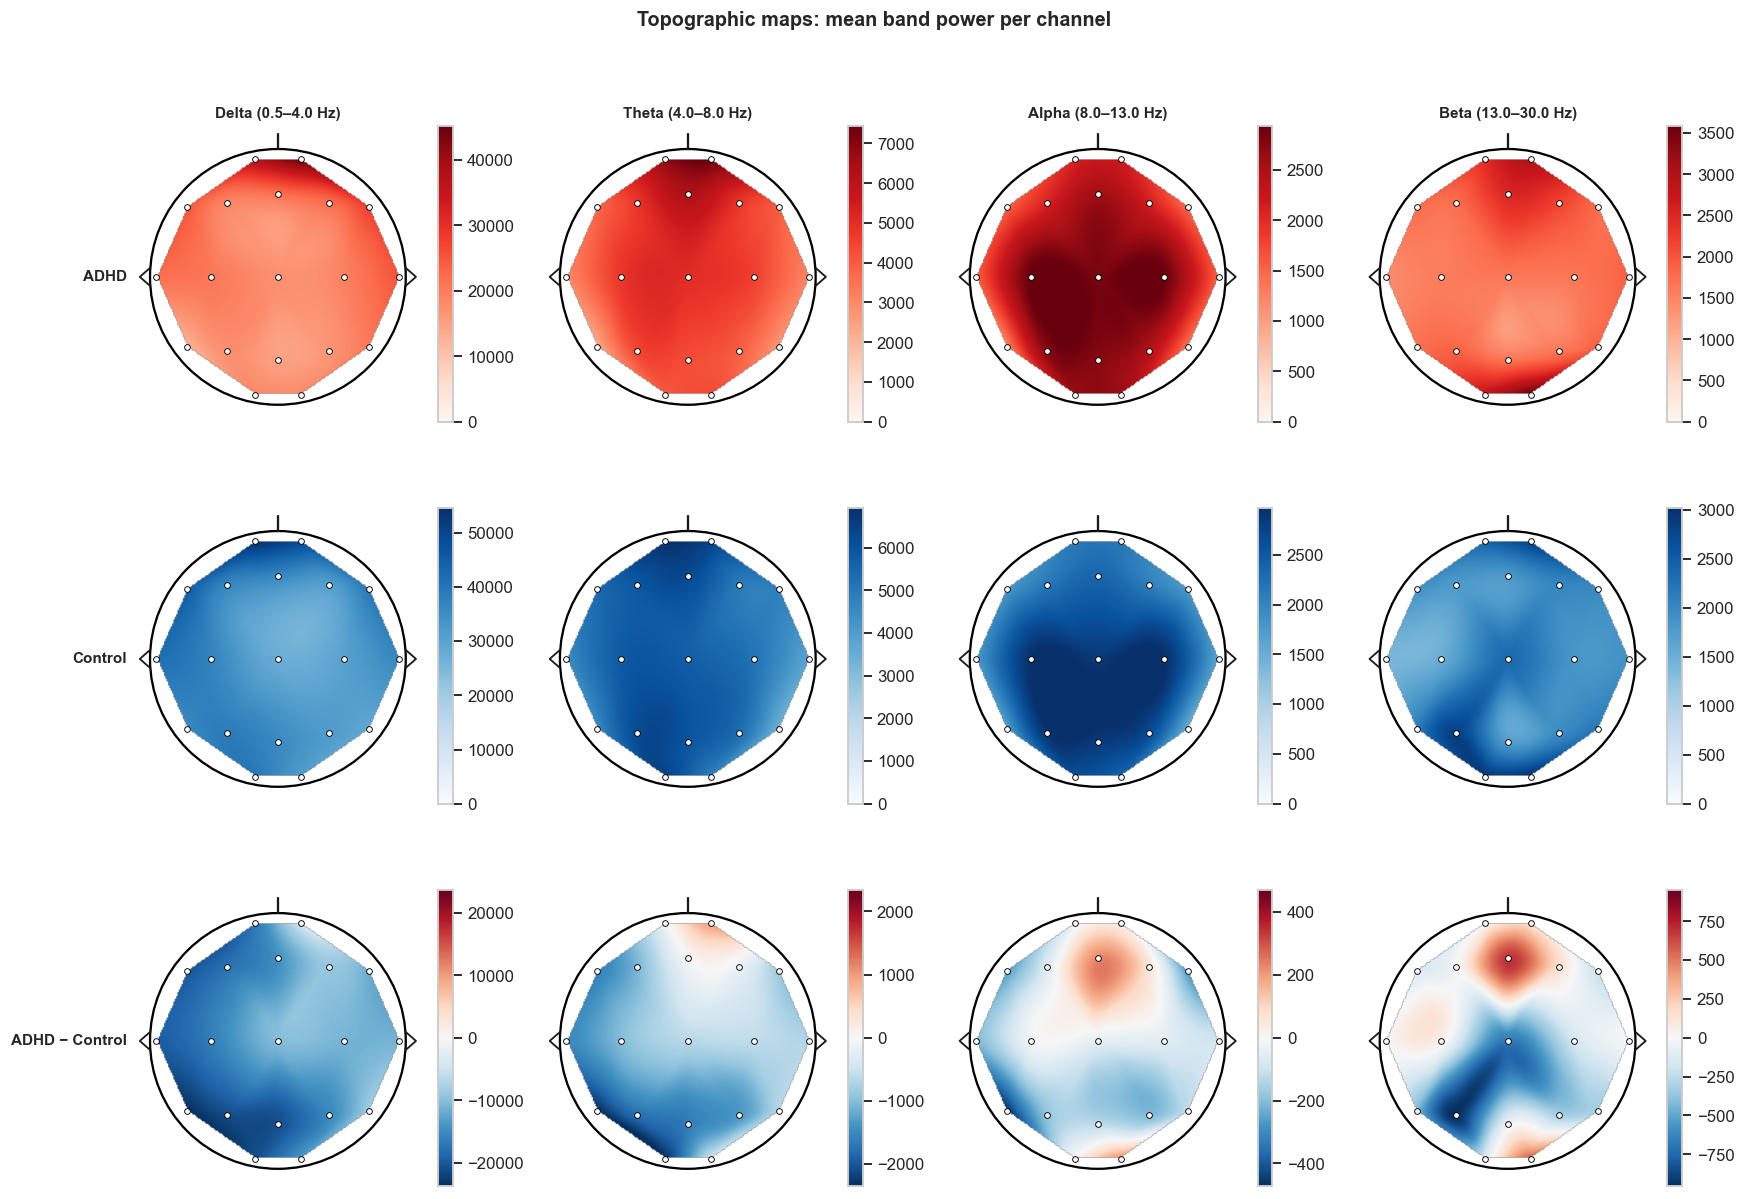

In [ ]:
bands      = list(FREQ_BANDS.keys())
row_labels = ['ADHD', 'Control', 'ADHD − Control']
row_data   = [adhd_topo, ctrl_topo, diff_topo]
row_cmaps  = ['Reds', 'Blues', 'RdBu_r']

fig, axes = plt.subplots(3, len(bands), figsize=(4 * len(bands), 11))

for row, (data_dict, cmap, row_lbl) in enumerate(zip(row_data, row_cmaps, row_labels)):
    for col, band in enumerate(bands):
        ax = axes[row, col]
        values = data_dict[band]
        vlim = np.abs(values).max()
        vmin, vmax = (-vlim, vlim) if row == 2 else (0, vlim)

        lo, hi = FREQ_BANDS[band]
        col_title = f'{band.capitalize()} ({lo}–{hi} Hz)' if row == 0 else ''
        im = plot_topomap(ax, values, EEG_CHANNELS, cmap, vmin, vmax, title=col_title)

        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

        if col == 0:
            ax.text(-1.18, 0.0, row_lbl, va='center', ha='right',
                    fontsize=10, fontweight='bold', transform=ax.transData)

plt.suptitle('Topographic maps: mean band power per channel', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


Theta/Alpha ratio (TAR)

C:\Users\kamil\AppData\Local\Temp\ipykernel_47352\2224585140.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=band_df, x='Class', y='theta_alpha_ratio', ax=ax,
C:\Users\kamil\AppData\Local\Temp\ipykernel_47352\2224585140.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=band_df, x='Class', y='theta_alpha_ratio', ax=ax,


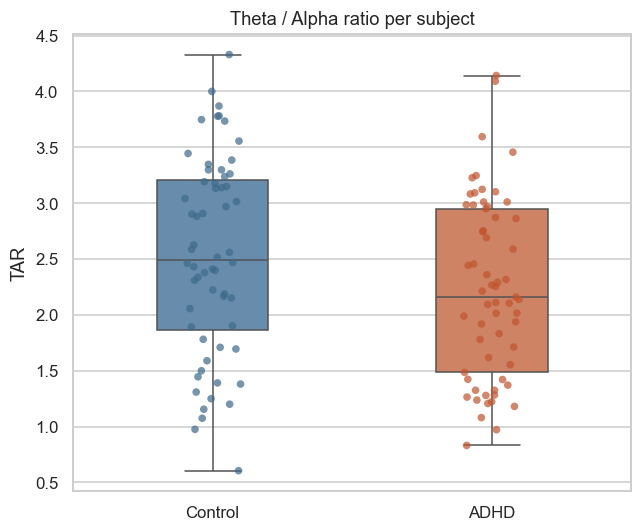

         count    mean     std     min     25%     50%     75%     max
Class                                                                 
ADHD      61.0  2.2308  0.8022  0.8315  1.4857  2.1589  2.9502  4.1428
Control   60.0  2.5286  0.8850  0.6056  1.8644  2.4926  3.2035  4.3302


In [ ]:
band_df['theta_alpha_ratio'] = band_df['theta'] / (band_df['alpha'] + 1e-12)

fig, ax = plt.subplots(figsize=(6, 5))
sns.boxplot(data=band_df, x='Class', y='theta_alpha_ratio', ax=ax,
            palette={'ADHD': '#e07b54', 'Control': '#5b8db8'}, width=0.4)
sns.stripplot(data=band_df, x='Class', y='theta_alpha_ratio', ax=ax,
              palette={'ADHD': '#c0552e', 'Control': '#3d6a8a'},
              size=5, alpha=0.7, jitter=True)
ax.set_title('Theta / Alpha ratio per subject')
ax.set_ylabel('TAR')
ax.set_xlabel('')
plt.tight_layout()
plt.show()

print(band_df.groupby('Class')['theta_alpha_ratio'].describe().round(4))

In [ ]:
from scipy.stats import mannwhitneyu, ttest_ind

adhd_tar = band_df[band_df['label'] == 1]['theta_alpha_ratio'].values
ctrl_tar  = band_df[band_df['label'] == 0]['theta_alpha_ratio'].values

stat_mw, p_mw = mannwhitneyu(adhd_tar, ctrl_tar, alternative='two-sided')

pooled_std = np.sqrt(
    ((len(adhd_tar) - 1) * adhd_tar.std(ddof=1)**2 + (len(ctrl_tar) - 1) * ctrl_tar.std(ddof=1)**2)
    / (len(adhd_tar) + len(ctrl_tar) - 2)
)
cohens_d = (adhd_tar.mean() - ctrl_tar.mean()) / pooled_std
n_adhd, n_ctrl = len(adhd_tar), len(ctrl_tar)
correction = 1 - (3 / (4 * (n_adhd + n_ctrl - 2) - 1))
hedges_g = cohens_d * correction

print(f"ADHD TAR:    mean={adhd_tar.mean():.3f}, std={adhd_tar.std():.3f}, n={n_adhd}")
print(f"Control TAR: mean={ctrl_tar.mean():.3f}, std={ctrl_tar.std():.3f}, n={n_ctrl}")

effect = "large" if abs(hedges_g) >= 0.8 else "medium" if abs(hedges_g) >= 0.5 else "small"
print(f"Mann-Whitney U={stat_mw:.1f}, p={p_mw:.4f}")
print(f"Hedges' g={hedges_g:.3f} ({effect})")

print("TAR difference (p < 0.05)." if p_mw < 0.05 else f"no TAR difference (p={p_mw:.3f}).")


ADHD TAR:    mean=2.231, std=0.796, n=61
Control TAR: mean=2.529, std=0.878, n=60
Mann-Whitney U=1426.0, p=0.0365
Hedges' g=-0.351 (small)
TAR difference (p < 0.05).


Channel correlation heatmap

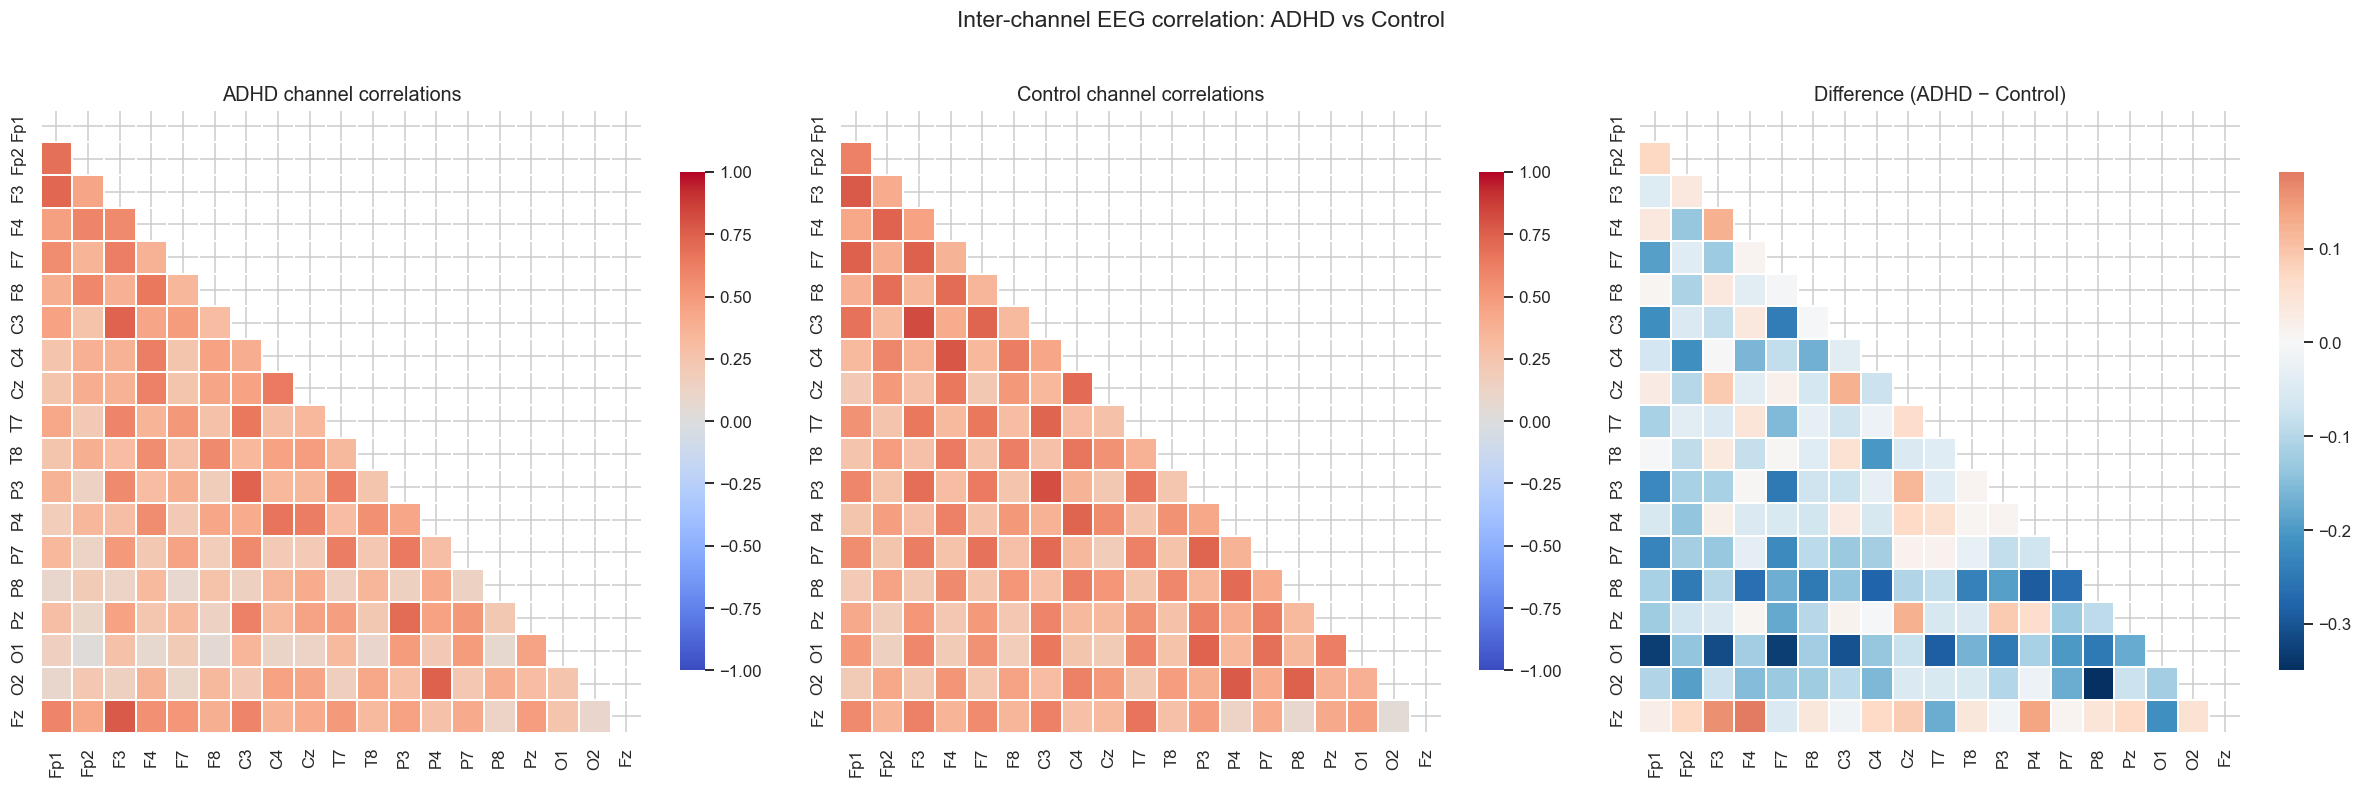

In [ ]:
sample_n = min(30000, len(df))
sample_corr = df.sample(n=sample_n, random_state=0)

adhd_corr = sample_corr[sample_corr['label'] == 1][EEG_CHANNELS].corr()
ctrl_corr  = sample_corr[sample_corr['label'] == 0][EEG_CHANNELS].corr()
diff_corr  = adhd_corr - ctrl_corr

tri_mask = np.triu(np.ones(len(EEG_CHANNELS), dtype=bool))

fig, axes = plt.subplots(1, 3, figsize=(22, 7))
configs = [
    (adhd_corr, 'ADHD channel correlations',   'coolwarm', -1,   1),
    (ctrl_corr, 'Control channel correlations', 'coolwarm', -1,   1),
    (diff_corr, 'Difference (ADHD − Control)',  'RdBu_r',  None, None),
]

for ax, (mat, title, cmap, vmin, vmax) in zip(axes, configs):
    kw = {'vmin': vmin, 'vmax': vmax} if vmin is not None else {}
    sns.heatmap(mat, mask=tri_mask, cmap=cmap, center=0,
                annot=False, linewidths=0.25, ax=ax,
                cbar_kws={'shrink': 0.8}, **kw)
    ax.set_title(title, fontsize=13)

plt.suptitle('Inter-channel EEG correlation: ADHD vs Control', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()


Subject-level variance

C:\Users\kamil\AppData\Local\Temp\ipykernel_47352\1060626412.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subj_std, x='Class', y='mean_std',
C:\Users\kamil\AppData\Local\Temp\ipykernel_47352\1060626412.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=subj_std, x='Class', y='mean_std',


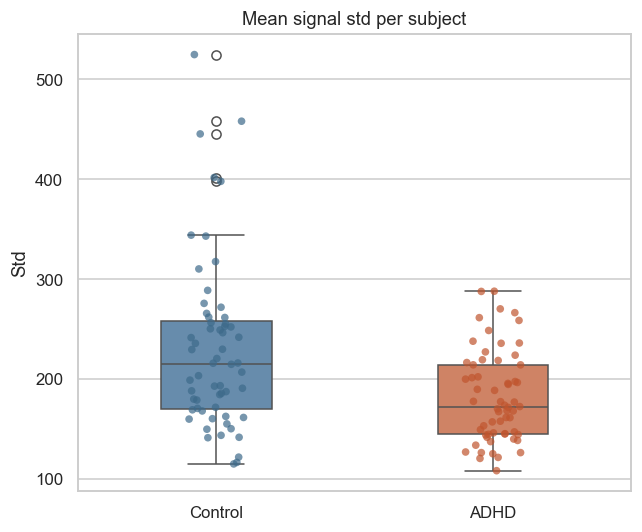

In [ ]:
subj_std = df.groupby(['ID', 'label'])[EEG_CHANNELS].std().mean(axis=1).reset_index()
subj_std.columns = ['ID', 'label', 'mean_std']
subj_std['Class'] = subj_std['label'].map({1: 'ADHD', 0: 'Control'})

fig, ax = plt.subplots(figsize=(6, 5))
sns.boxplot(data=subj_std, x='Class', y='mean_std',
            palette={'ADHD': '#e07b54', 'Control': '#5b8db8'},
            width=0.4, ax=ax)
sns.stripplot(data=subj_std, x='Class', y='mean_std',
              palette={'ADHD': '#c0552e', 'Control': '#3d6a8a'},
              size=5, alpha=0.7, jitter=True, ax=ax)
ax.set_title('Mean signal std per subject')
ax.set_ylabel('Std')
ax.set_xlabel('')
plt.tight_layout()
plt.show()

Neural oscillations

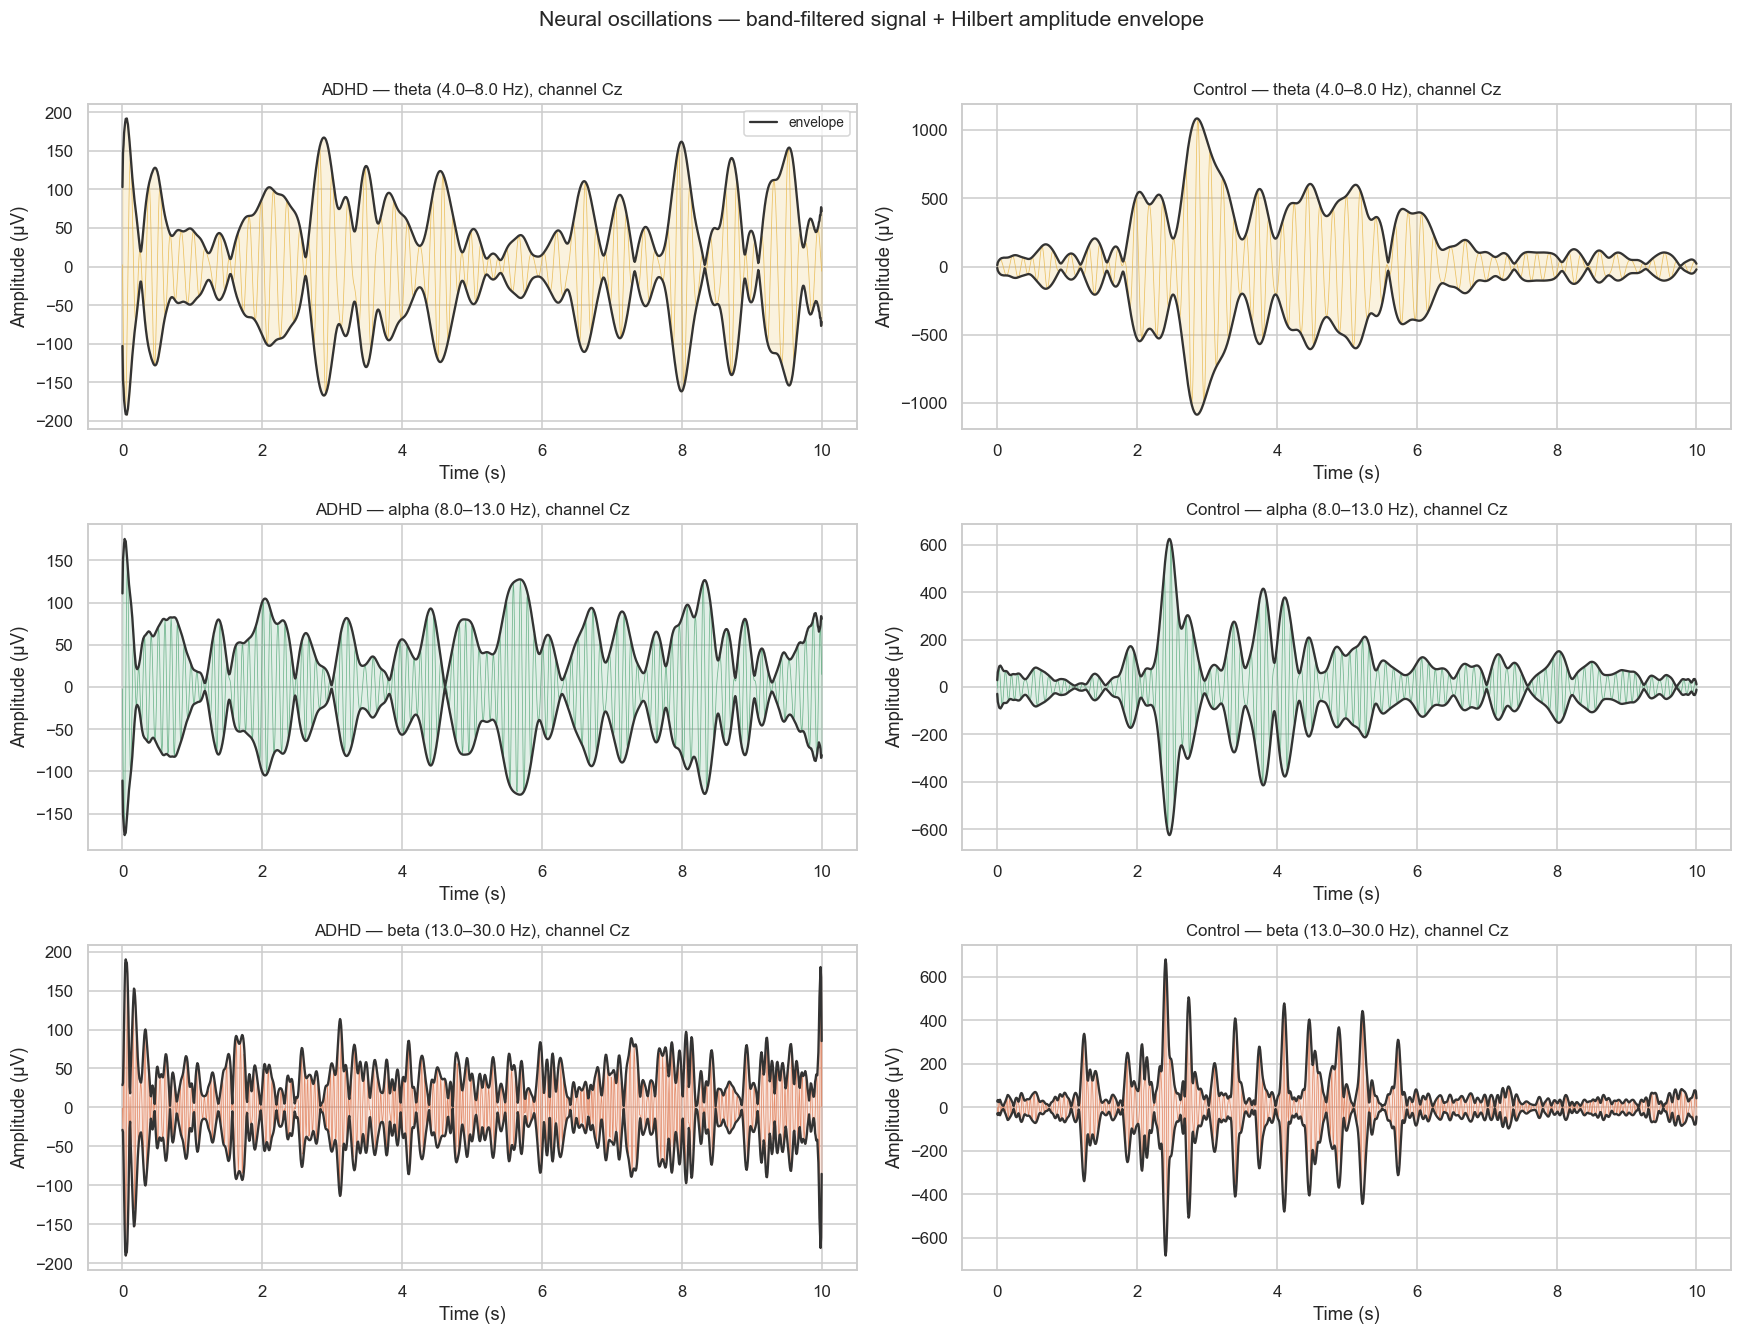

In [ ]:
from scipy.signal import hilbert

BANDS_OSC = [
    ('theta', 4.0,  8.0,  '#e8b84b'),
    ('alpha', 8.0,  13.0, '#5aaa7c'),
    ('beta',  13.0, 30.0, '#e07b54'),
]

OSC_CH = 'Cz'
WINDOW = int(10 * SAMPLING_FREQ)

adhd_raw = df[df['ID'] == adhd_id][OSC_CH].values
ctrl_raw = df[df['ID'] == ctrl_id][OSC_CH].values

fig, axes = plt.subplots(len(BANDS_OSC), 2, figsize=(16, 4 * len(BANDS_OSC)))

for row, (name, lo, hi, color) in enumerate(BANDS_OSC):
    for col, (sig, title) in enumerate([(adhd_raw, 'ADHD'), (ctrl_raw, 'Control')]):
        ax = axes[row, col]
        filt = bandpass_filter(sig[:WINDOW].reshape(-1, 1), lo=lo, hi=hi).ravel()
        env  = np.abs(hilbert(filt))
        t    = np.linspace(0, WINDOW / SAMPLING_FREQ, WINDOW)

        ax.fill_between(t, -env, env, alpha=0.18, color=color)
        ax.plot(t, filt, lw=0.5, color=color, alpha=0.85)
        ax.plot(t,  env, lw=1.5, color='#333333', label='envelope')
        ax.plot(t, -env, lw=1.5, color='#333333')
        ax.set_title(f'{title} — {name} ({lo}–{hi} Hz), channel {OSC_CH}', fontsize=11)
        ax.set_ylabel('Amplitude (µV)')
        ax.set_xlabel('Time (s)')
        if row == 0 and col == 0:
            ax.legend(fontsize=9)

plt.suptitle('Neural oscillations — band-filtered signal + Hilbert amplitude envelope', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()
